#Task 1: Data Preparation and Exploration

Cell 1: Import required libraries

In [108]:
# Basic data handling and visualization
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Data normalization
from sklearn.preprocessing import StandardScaler

# For manual SMOTE (nearest neighbors)
from sklearn.neighbors import NearestNeighbors


Cell 2: Load the dataset from UCI repository (CSV)

In [109]:
# Load Pima Indians Diabetes dataset (replace with local file path if needed)
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
column_names = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
                'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df = pd.read_csv(url, header=None, names=column_names)

# Show first few rows
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


Cell 3: Remove invalid records (e.g., Glucose = 0)

In [110]:
# Remove entries with zero in medically invalid fields
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_cols:
    df = df[df[col] != 0]

df.shape


(392, 9)

Cell 4: Plot feature distributions before normalization

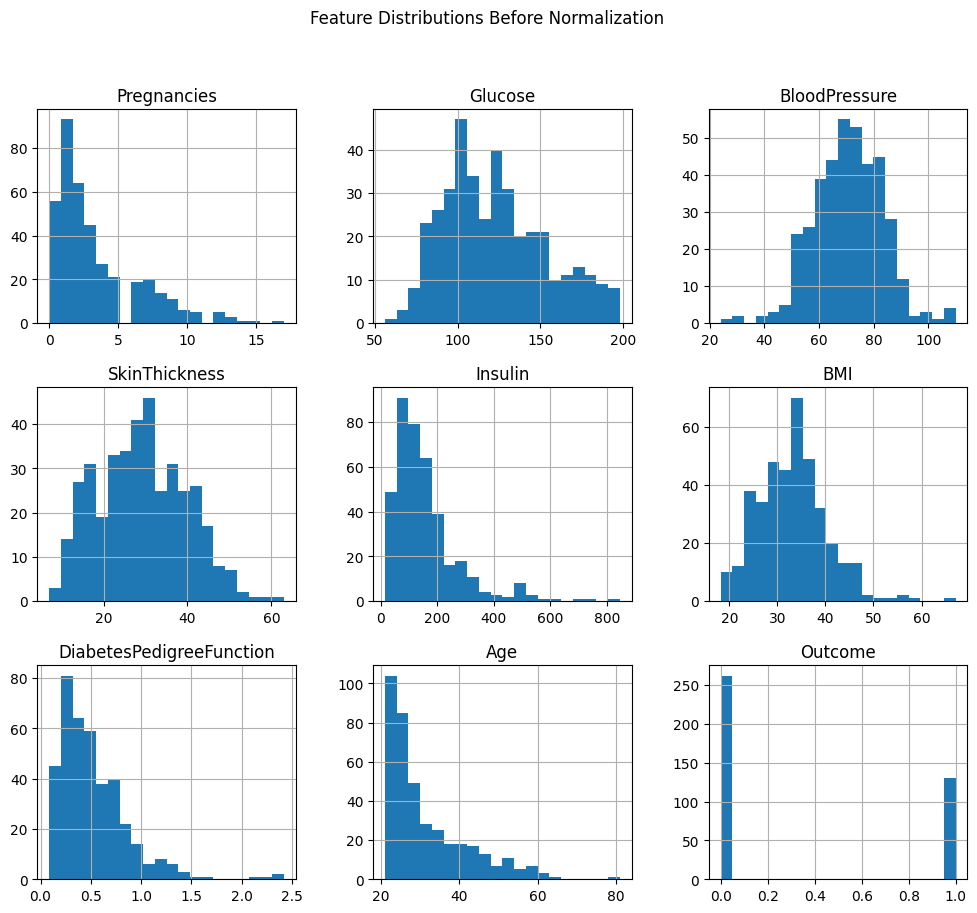

In [111]:
# Plot histograms of original feature values
df.hist(bins=20, figsize=(12, 10))
plt.suptitle("Feature Distributions Before Normalization")
plt.show()


 Cell 5: Normalize features using Z-score

In [112]:
# Normalize features (excluding the label column)
features = df.columns[:-1]
scaler = StandardScaler()
df[features] = scaler.fit_transform(df[features])

# Display normalized data
df.head()


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
3,-0.717427,-1.091046,-0.373655,-0.585110,-0.522842,-0.710421,-1.031876,-0.968299,0
4,-1.029213,0.466314,-2.456964,0.557421,0.100631,1.426730,5.115111,0.209585,1
6,-0.093854,-1.447941,-1.655691,0.271788,-0.573394,-0.297238,-0.797126,-0.477514,1
8,-0.405640,2.413014,-0.053146,1.509530,3.260122,-0.368477,-1.057960,2.172726,1
13,-0.717427,2.153454,-0.854419,-0.585110,5.812990,-0.425468,-0.362402,2.761668,1


Cell 6: Plot feature distributions after normalization

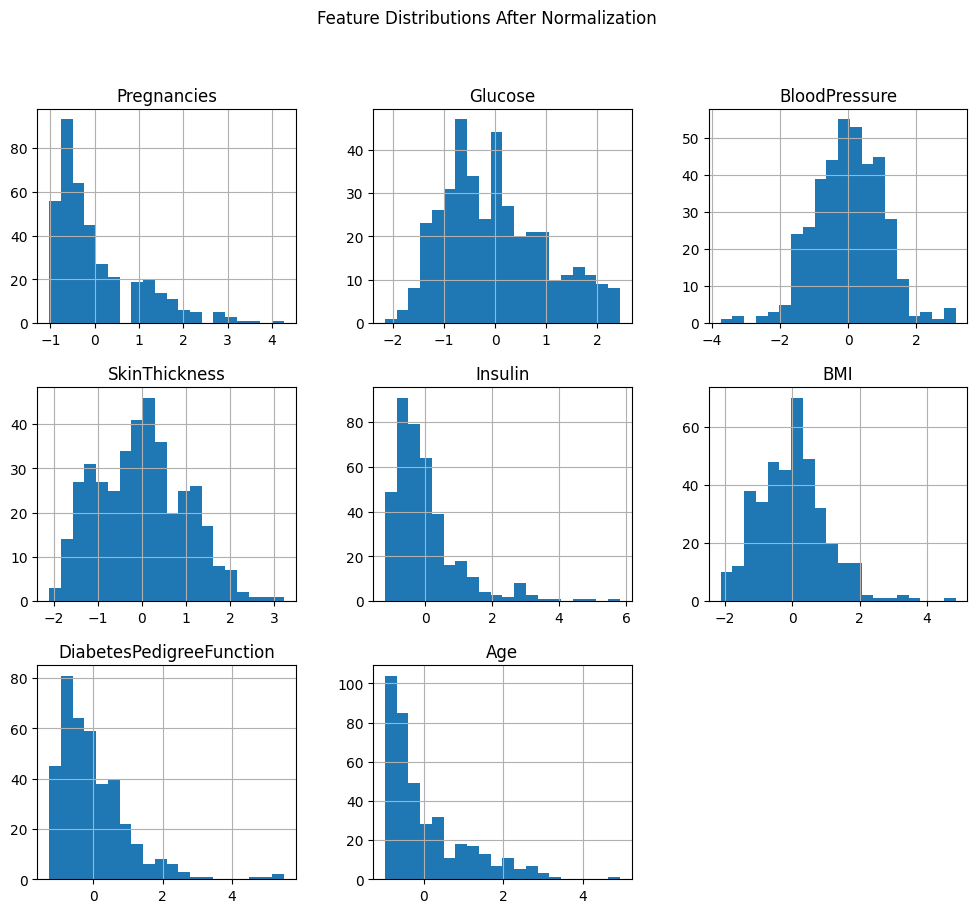

In [113]:
# Histogram of normalized features
df[features].hist(bins=20, figsize=(12, 10))
plt.suptitle("Feature Distributions After Normalization")
plt.show()


Cell 7: Correlation heatmap

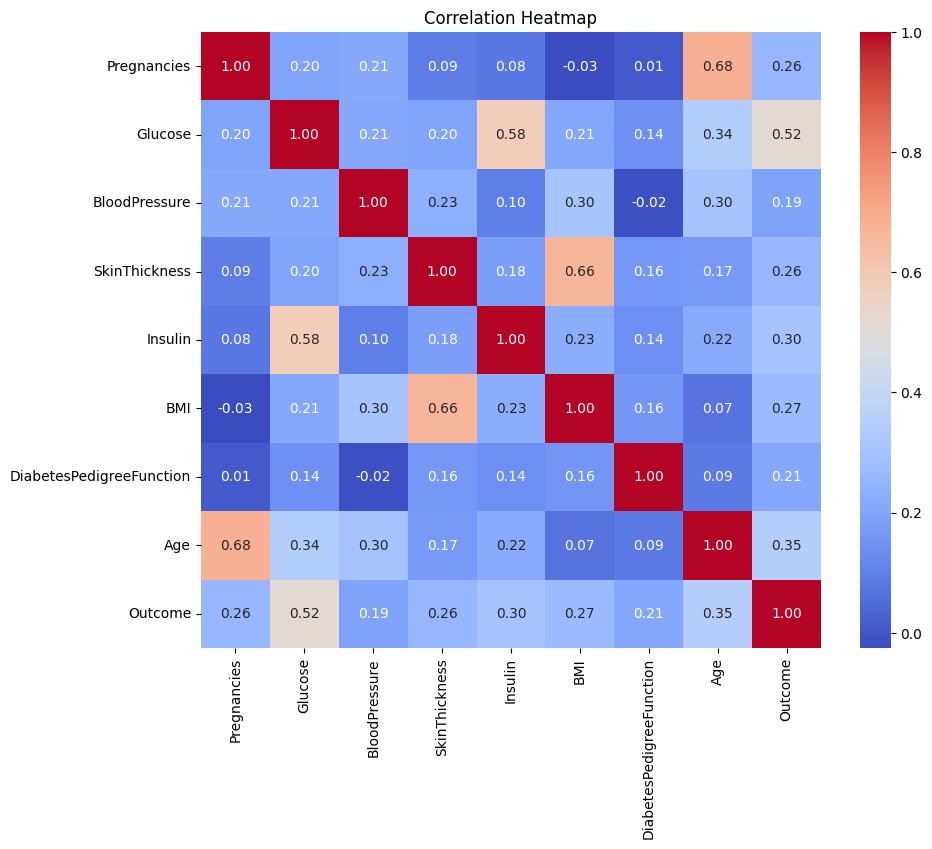

In [114]:
# Show correlation heatmap among features
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


Cell 8: Check class imbalance

In [115]:
# Check class distribution (Outcome 0 vs 1)
class_dist = df['Outcome'].value_counts(normalize=True)
print("Class distribution:\n", class_dist)


Class distribution:
 Outcome
0    0.668367
1    0.331633
Name: proportion, dtype: float64


 Cell 9: Manual SMOTE implementation

In [116]:
# Separate features and labels
X = df.drop('Outcome', axis=1)
y = df['Outcome']

# Separate minority and majority class samples
X_min = X[y == 1].copy()
X_maj = X[y == 0].copy()

n_min, n_maj = len(X_min), len(X_maj)
n_synthetic = n_maj - n_min

# Fit k-NN on minority class
k = 5
nn = NearestNeighbors(n_neighbors=k+1)
nn.fit(X_min)
neighbors = nn.kneighbors(X_min, return_distance=False)[:, 1:]  # exclude self

# Generate synthetic samples
synthetic_samples = []
np.random.seed(42)
for _ in range(n_synthetic):
    i = np.random.randint(0, n_min)
    neighbor = np.random.choice(neighbors[i])
    sample_i = X_min.iloc[i].values
    sample_n = X_min.iloc[neighbor].values
    gap = np.random.rand()
    synthetic = sample_i + gap * (sample_n - sample_i)
    synthetic_samples.append(synthetic)

# Combine synthetic data with original data
X_syn = pd.DataFrame(synthetic_samples, columns=X.columns)
y_syn = pd.Series([1] * n_synthetic)

X_balanced = pd.concat([X_maj, X_min, X_syn], ignore_index=True)
y_balanced = pd.concat([pd.Series([0]*len(X_maj)), pd.Series([1]*n_min), y_syn], ignore_index=True)


Cell 10: Class distribution after SMOTE

In [117]:
# Show new class distribution after balancing
print("Class distribution after manual SMOTE:\n", y_balanced.value_counts(normalize=True))


Class distribution after manual SMOTE:
 0    0.5
1    0.5
Name: proportion, dtype: float64


#Task 2 – Model 1: Logistic Regression with Newton’s Method

 Cell 1: Import libraries

In [118]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Cell 2: Prepare the balanced dataset

In [119]:
# Assuming X_balanced and y_balanced already exist from Task 1
X = X_balanced.copy()
y = y_balanced.copy().values.reshape(-1, 1)

# Add bias term (intercept)
X.insert(0, 'bias', 1)
X = X.values


Cell 3: Define sigmoid and log-likelihood functions

In [120]:
# Sigmoid function
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

# Log-likelihood
def log_likelihood(X, y, w):
    z = X @ w
    ll = np.sum(y * z - np.log(1 + np.exp(z)))
    return ll


Cell 4: Define gradient and Hessian functions

In [121]:
# Gradient of log-likelihood
def gradient(X, y, w):
    h = sigmoid(X @ w)
    return X.T @ (y - h)

# Hessian matrix
def hessian(X, w):
    h = sigmoid(X @ w)
    S = np.diag((h * (1 - h)).flatten())
    return -X.T @ S @ X


Cell 5: Train model using Newton's Method

In [122]:
# Initialize weights
w = np.zeros((X.shape[1], 1))

# Training loop
ll_history = []
for i in range(10):  # Limit to 10 iterations
    grad = gradient(X, y, w)
    H = hessian(X, w)
    delta = np.linalg.inv(H) @ grad
    w -= delta
    ll = log_likelihood(X, y, w)
    ll_history.append(ll)
    print(f"Iteration {i+1}, Log-Likelihood: {ll:.4f}")


Iteration 1, Log-Likelihood: -250.1642
Iteration 2, Log-Likelihood: -240.5824
Iteration 3, Log-Likelihood: -240.0628
Iteration 4, Log-Likelihood: -240.0603
Iteration 5, Log-Likelihood: -240.0603
Iteration 6, Log-Likelihood: -240.0603
Iteration 7, Log-Likelihood: -240.0603
Iteration 8, Log-Likelihood: -240.0603
Iteration 9, Log-Likelihood: -240.0603
Iteration 10, Log-Likelihood: -240.0603


Cell 6: Plot log-likelihood convergence

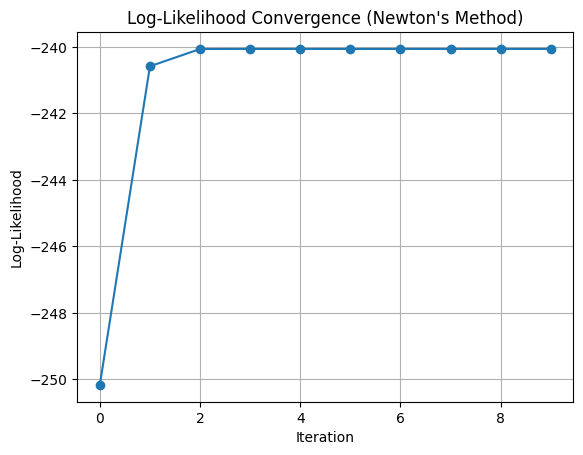

In [123]:
plt.plot(ll_history, marker='o')
plt.title("Log-Likelihood Convergence (Newton's Method)")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()


Cell 7: Prediction and Evaluation Metrics

In [124]:
# Predict probabilities using the learned weights
y_prob = sigmoid(X @ w)

# Convert probabilities to binary predictions (threshold = 0.5)
y_pred = (y_prob >= 0.5).astype(int)

# Calculate evaluation metrics manually
def evaluate(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()

    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

# Run evaluation
evaluate(y, y_pred)


Accuracy:  0.7729
Precision: 0.7826
Recall:    0.7557
F1 Score:  0.7689


# Task 2 – Model 2: Softmax Regression for Age Classification

 Cell 1: Import required libraries

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Cell 2: Load original dataset and remove invalid rows

In [126]:
# Load original dataset
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
cols = ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
        'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']
df_raw = pd.read_csv(url, header=None, names=cols)

# Remove invalid values (0) in specific columns
invalid_cols = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
for col in invalid_cols:
    df_raw = df_raw[df_raw[col] != 0]


Cell 3: Create age classes and apply manual oversampling

In [127]:
# Create age classes
age_bins = [0, 30, 50, np.inf]
age_labels = [0, 1, 2]  # 0: Young, 1: Middle-aged, 2: Elderly
df_raw['age_class'] = pd.cut(df_raw['Age'], bins=age_bins, labels=age_labels, include_lowest=True)

# Drop NaNs (if any)
df_raw = df_raw.dropna(subset=['age_class'])
df_raw['age_class'] = df_raw['age_class'].astype(int)

# Oversample classes 1 and 2 to match class 0
class_0 = df_raw[df_raw['age_class'] == 0]
class_1 = df_raw[df_raw['age_class'] == 1]
class_2 = df_raw[df_raw['age_class'] == 2]
target_size = len(class_0)

resample_1 = class_1.sample(target_size, replace=True, random_state=0)
resample_2 = class_2.sample(target_size, replace=True, random_state=0)

df_balanced = pd.concat([class_0, resample_1, resample_2], ignore_index=True)


Cell 4: Prepare X and y

In [128]:
# Extract X and y
y_softmax = df_balanced['age_class'].values
X_softmax = df_balanced.drop(['Outcome', 'age_class'], axis=1).copy()
X_softmax.insert(0, 'bias', 1)  # Add bias term
X_softmax = X_softmax.values

# Check class distribution
print(pd.Series(y_softmax).value_counts())


0    248
1    248
2    248
Name: count, dtype: int64


Cell 5: Define softmax and helper functions

In [129]:
# Softmax function
def softmax(z):
    z -= np.max(z, axis=1, keepdims=True)  # log-sum-exp trick
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

# One-hot encoding
def one_hot(y, num_classes):
    m = y.shape[0]
    onehot = np.zeros((m, num_classes))
    onehot[np.arange(m), y] = 1
    return onehot

# Log-likelihood
def softmax_log_likelihood(X, y_onehot, W):
    probs = softmax(X @ W)
    return np.sum(y_onehot * np.log(probs + 1e-9))


Cell 6: Initialize weights and train with gradient descent

In [130]:
# Dimensions
m, n = X_softmax.shape
k = 3  # 3 age classes

W = np.zeros((n, k))  # Initialize weights
y_onehot = one_hot(y_softmax, k)

# Training loop
alpha = 0.1
loss_history = []

for i in range(100):
    z = X_softmax @ W
    probs = softmax(z)
    grad = X_softmax.T @ (y_onehot - probs)
    W += alpha * grad / m
    loss = softmax_log_likelihood(X_softmax, y_onehot, W)
    loss_history.append(loss)
    if i % 10 == 0:
        print(f"Iteration {i}, Log-Likelihood: {loss:.4f}")


Iteration 0, Log-Likelihood: -10278.7399
Iteration 10, Log-Likelihood: -9459.8951
Iteration 20, Log-Likelihood: -8332.8920
Iteration 30, Log-Likelihood: -10112.2663
Iteration 40, Log-Likelihood: -10258.0241
Iteration 50, Log-Likelihood: -8164.9641
Iteration 60, Log-Likelihood: -9730.4417
Iteration 70, Log-Likelihood: -8451.0661
Iteration 80, Log-Likelihood: -7037.2708
Iteration 90, Log-Likelihood: -8190.4566


Cell 7: Plot log-likelihood over iterations

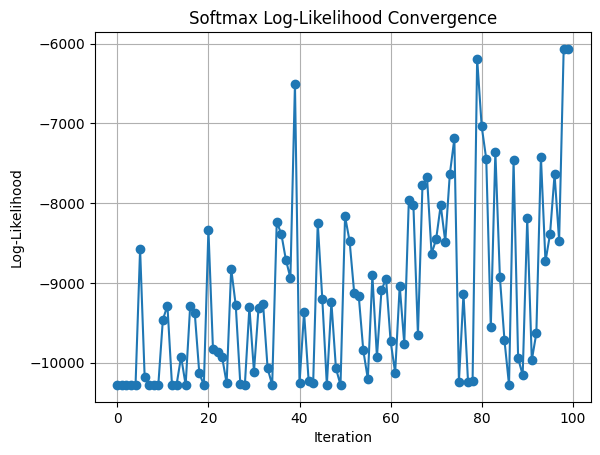

In [131]:
plt.plot(loss_history, marker='o')
plt.title("Softmax Log-Likelihood Convergence")
plt.xlabel("Iteration")
plt.ylabel("Log-Likelihood")
plt.grid(True)
plt.show()

 Cell 8: Predict and evaluate

In [132]:
# Predict
probs = softmax(X_softmax @ W)
y_pred = np.argmax(probs, axis=1)

# Accuracy
accuracy = np.mean(y_pred == y_softmax)
print(f"Accuracy: {accuracy:.4f}")

# Confusion Matrix
conf_matrix = np.zeros((3, 3), dtype=int)
for t, p in zip(y_softmax, y_pred):
    conf_matrix[t, p] += 1
print("\nConfusion Matrix (true ↓, predicted →):")
print(conf_matrix)

# Per-class metrics
for c in range(3):
    TP = conf_matrix[c, c]
    FP = conf_matrix[:, c].sum() - TP
    FN = conf_matrix[c, :].sum() - TP
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)
    print(f"\nClass {c}:")
    print(f"  Precision: {precision:.4f}")
    print(f"  Recall:    {recall:.4f}")
    print(f"  F1 Score:  {f1:.4f}")


Accuracy: 0.6062

Confusion Matrix (true ↓, predicted →):
[[237   0  11]
 [188   0  60]
 [ 34   0 214]]

Class 0:
  Precision: 0.5163
  Recall:    0.9556
  F1 Score:  0.6704

Class 1:
  Precision: 0.0000
  Recall:    0.0000
  F1 Score:  0.0000

Class 2:
  Precision: 0.7509
  Recall:    0.8629
  F1 Score:  0.8030


#Task 2 – Model 3: LDA (Linear Discriminant Analysis)

Cell 1: Import libraries

In [133]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


 Cell 2: Prepare dataset (same format as Logistic Regression)

In [134]:
# Use the diabetes dataset after cleaning (e.g., df from Task 1)
# Reuse normalized and cleaned data
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].values

# Shape info
print(f"Features shape: {X.shape}")
print(f"Class distribution:\n{pd.Series(y).value_counts()}")


Features shape: (392, 8)
Class distribution:
0    262
1    130
Name: count, dtype: int64


 Cell 3: Estimate LDA parameters (ϕ, μ0, μ1, Σ)

In [135]:
# Split data by class
X0 = X[y == 0]
X1 = X[y == 1]

# Prior probabilities
phi = len(X1) / len(X)

# Class means
mu0 = X0.mean().values.reshape(-1, 1)
mu1 = X1.mean().values.reshape(-1, 1)

# Shared covariance matrix (pooled)
m0 = len(X0)
m1 = len(X1)
X0_centered = X0 - mu0.ravel()
X1_centered = X1 - mu1.ravel()
Sigma = (X0_centered.T @ X0_centered + X1_centered.T @ X1_centered) / (m0 + m1)


Cell 4: Define LDA decision function

In [136]:
# Inverse of shared covariance
Sigma_inv = np.linalg.inv(Sigma)

# Compute linear scores for each class
def lda_predict(X_input):
    X_mat = X_input.values if isinstance(X_input, pd.DataFrame) else X_input
    X_mat = X_mat.T

    w = Sigma_inv @ (mu1 - mu0)
    b = (-0.5 * mu1.T @ Sigma_inv @ mu1 +
         0.5 * mu0.T @ Sigma_inv @ mu0 +
         np.log(phi / (1 - phi)))

    z = (w.T @ X_mat + b).flatten()
    return (z > 0).astype(int)


Cell 5: Run prediction and evaluation

In [137]:
# Run predictions
y_pred_lda = lda_predict(X)

# Evaluation
def evaluate_binary(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

evaluate_binary(y, y_pred_lda)


Accuracy:  0.7857
Precision: 0.7170
Recall:    0.5846
F1 Score:  0.6441


Cell 6: Visualize LDA Decision Boundary

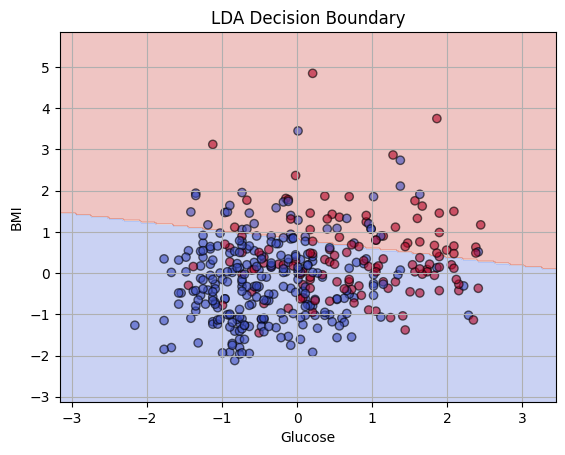

In [138]:
# Choose 2 features for visualization (e.g., Glucose and BMI)
feature1 = 'Glucose'
feature2 = 'BMI'

# Generate meshgrid
x_min, x_max = X[feature1].min() - 1, X[feature1].max() + 1
y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict over the grid
grid = pd.DataFrame({feature1: xx.ravel(), feature2: yy.ravel()})
for col in X.columns:
    if col not in grid.columns:
        grid[col] = 0  # set others to 0

Z = lda_predict(grid).reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[feature1], X[feature2], c=y, edgecolor='k', cmap='coolwarm', alpha=0.6)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("LDA Decision Boundary")
plt.grid(True)
plt.show()


#Task 2 – Model 4: QDA (Quadratic Discriminant Analysis)

 Cell 1: Import required libraries

In [139]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


 Cell 2: Prepare dataset

In [140]:
# Reuse cleaned and normalized df (from Task 1)
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].values

# Split data by class
X0 = X[y == 0]
X1 = X[y == 1]

# Convert to numpy
X0_np = X0.values
X1_np = X1.values


Cell 3: Estimate QDA parameters (ϕ, μ0, μ1, Σ0, Σ1)

In [141]:
# Class priors
phi0 = len(X0_np) / len(X)
phi1 = len(X1_np) / len(X)

# Class means
mu0 = np.mean(X0_np, axis=0)
mu1 = np.mean(X1_np, axis=0)

# Class covariance matrices
Sigma0 = np.cov(X0_np, rowvar=False)
Sigma1 = np.cov(X1_np, rowvar=False)


Cell 4: Define QDA decision function

In [142]:
# Multivariate Gaussian log-pdf
def log_gaussian_pdf(x, mu, Sigma):
    size = len(mu)
    det = np.linalg.det(Sigma)
    inv = np.linalg.inv(Sigma)
    norm_const = -0.5 * (np.log(det) + size * np.log(2 * np.pi))
    x_mu = x - mu
    result = norm_const - 0.5 * (x_mu @ inv @ x_mu.T)
    return result

# QDA prediction function
def qda_predict(X_input):
    predictions = []
    for x in X_input:
        log_p0 = log_gaussian_pdf(x, mu0, Sigma0) + np.log(phi0)
        log_p1 = log_gaussian_pdf(x, mu1, Sigma1) + np.log(phi1)
        predictions.append(1 if log_p1 > log_p0 else 0)
    return np.array(predictions)


Cell 5: Predict and evaluate

In [143]:
# Predict
y_pred_qda = qda_predict(X.values)

# Evaluate
def evaluate_binary(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

evaluate_binary(y, y_pred_qda)


Accuracy:  0.8061
Precision: 0.7288
Recall:    0.6615
F1 Score:  0.6935


Cell 6: Visualize nonlinear decision boundary

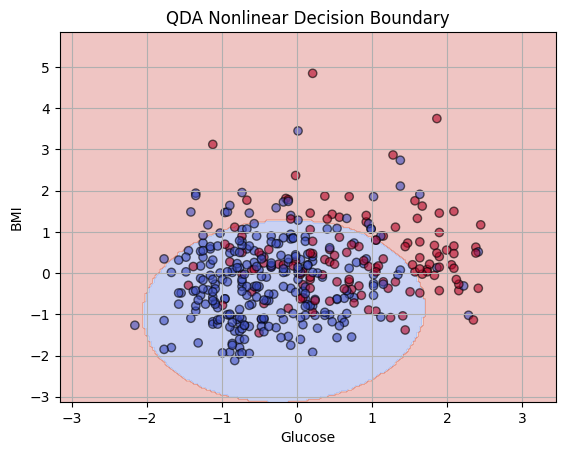

In [144]:
# Choose 2 features (e.g., Glucose and BMI)
feature1 = 'Glucose'
feature2 = 'BMI'

# Meshgrid
x_min, x_max = X[feature1].min() - 1, X[feature1].max() + 1
y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Predict grid
grid = pd.DataFrame({feature1: xx.ravel(), feature2: yy.ravel()})
for col in X.columns:
    if col not in grid.columns:
        grid[col] = 0  # Set unused features to 0

Z = qda_predict(grid.values).reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[feature1], X[feature2], c=y, cmap='coolwarm', edgecolor='k', alpha=0.6)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("QDA Nonlinear Decision Boundary")
plt.grid(True)
plt.show()


# Task 2 – Model 5: Gaussian Naive Bayes

Cell 1: Import libraries

In [145]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


Cell 2: Prepare dataset

In [146]:
# Use normalized and cleaned dataset (from Task 1)
X = df.drop('Outcome', axis=1).copy()
y = df['Outcome'].values

# Convert to numpy for speed
X_np = X.values


 Cell 3: Estimate parameters for Gaussian Naive Bayes

In [147]:
# Split data by class
X0 = X_np[y == 0]
X1 = X_np[y == 1]

# Priors
phi0 = len(X0) / len(X_np)
phi1 = len(X1) / len(X_np)

# For each feature, compute class-conditional mean and variance
mu0 = np.mean(X0, axis=0)
var0 = np.var(X0, axis=0) + 1e-6  # add small value for numerical stability

mu1 = np.mean(X1, axis=0)
var1 = np.var(X1, axis=0) + 1e-6


 Cell 4: Define prediction function

In [148]:
# Gaussian likelihood (log form)
def gaussian_log_prob(x, mu, var):
    return -0.5 * np.sum(np.log(2 * np.pi * var)) - 0.5 * np.sum(((x - mu) ** 2) / var)

# Naive Bayes prediction
def nb_predict(X_input):
    preds = []
    for x in X_input:
        log_p0 = gaussian_log_prob(x, mu0, var0) + np.log(phi0)
        log_p1 = gaussian_log_prob(x, mu1, var1) + np.log(phi1)
        preds.append(1 if log_p1 > log_p0 else 0)
    return np.array(preds)


 Cell 5: Predict and evaluate

In [149]:
# Predict
y_pred_nb = nb_predict(X_np)

# Evaluate
def evaluate_binary(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

evaluate_binary(y, y_pred_nb)


Accuracy:  0.7781
Precision: 0.6693
Recall:    0.6538
F1 Score:  0.6615


Cell 6: Visualize decision boundary

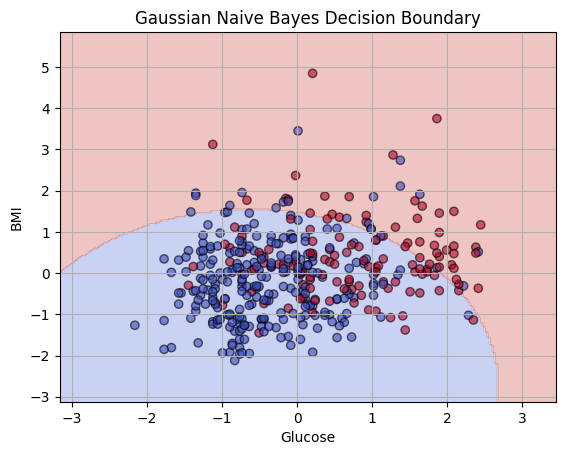

In [150]:
# Select 2 features
feature1 = 'Glucose'
feature2 = 'BMI'

# Create grid
x_min, x_max = X[feature1].min() - 1, X[feature1].max() + 1
y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1
xx, yy = np.meshgrid(np.linspace(x_min, x_max, 200),
                     np.linspace(y_min, y_max, 200))

# Create grid input
grid = pd.DataFrame({feature1: xx.ravel(), feature2: yy.ravel()})
for col in X.columns:
    if col not in grid.columns:
        grid[col] = 0  # zero for unused features

Z = nb_predict(grid.values).reshape(xx.shape)

# Plot
plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
plt.scatter(X[feature1], X[feature2], c=y, cmap='coolwarm', edgecolor='k', alpha=0.6)
plt.xlabel(feature1)
plt.ylabel(feature2)
plt.title("Gaussian Naive Bayes Decision Boundary")
plt.grid(True)
plt.show()


#Task 4 – Numerical Evaluation and Boundary Visualization

Cell 1: Evaluation & Visualization Utilities

In [151]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

def evaluate_all(y_true, y_pred, y_prob=None):
    print("Accuracy:  ", round(accuracy_score(y_true, y_pred), 4))
    print("Precision: ", round(precision_score(y_true, y_pred), 4))
    print("Recall:    ", round(recall_score(y_true, y_pred), 4))
    print("F1 Score:  ", round(f1_score(y_true, y_pred), 4))
    if y_prob is not None:
        print("ROC-AUC:   ", round(roc_auc_score(y_true, y_prob), 4))

def add_gaussian_noise(X, std=0.1):
    return X + np.random.normal(0, std, X.shape)

def remove_feature(X_df, feature='BMI'):
    return X_df.drop(columns=[feature], errors='ignore')

def add_outliers(X_df, feature='Glucose', num=10, extreme_value=5):
    X_new = X_df.copy()
    idx = np.random.choice(X_new.index, size=num, replace=False)
    X_new.loc[idx, feature] += extreme_value * X_new[feature].std()
    return X_new

def plot_decision_boundary(predict_fn, X_df, y, feature1='Glucose', feature2='BMI', title='Boundary'):
    x_min, x_max = X_df[feature1].min() - 1, X_df[feature1].max() + 1
    y_min, y_max = X_df[feature2].min() - 1, X_df[feature2].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    grid = pd.DataFrame({feature1: xx.ravel(), feature2: yy.ravel()})
    for col in X_df.columns:
        if col not in grid:
            grid[col] = 0

    Z = predict_fn(grid.values).reshape(xx.shape)

    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z, alpha=0.3, cmap='coolwarm')
    plt.scatter(X_df[feature1], X_df[feature2], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
    plt.title(title)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.grid(True)
    plt.show()


Cell 2: Evaluation Template for Each Model

1. Logistic Regression – logreg_predict(X)

 Logistic Regression on original:
Accuracy:   0.7832
Precision:  0.7184
Recall:     0.5692
F1 Score:   0.6352


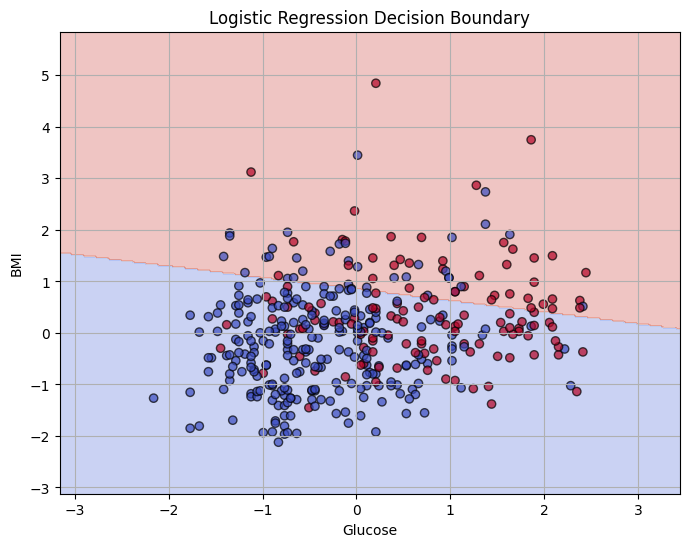


 Logistic Regression with Noise:
Accuracy:   0.7806
Precision:  0.7157
Recall:     0.5615
F1 Score:   0.6293

 Logistic Regression without BMI:
Accuracy:   0.801
Precision:  0.7708
Recall:     0.5692
F1 Score:   0.6549

 Logistic Regression with Outliers:
Accuracy:   0.7704
Precision:  0.6818
Recall:     0.5769
F1 Score:   0.625


In [152]:
# Assumes: weights 'w_logreg' are already trained (shape: [n_features+1, 1])
# X input should be numpy array without bias → we will add bias here

# Example (training via Newton's Method)
X_train = X.copy()
X_train.insert(0, 'bias', 1)
X_np = X_train.values
w_logreg = np.zeros((X_np.shape[1], 1))

# Train loop
for i in range(10):
    h = sigmoid(X_np @ w_logreg)
    grad = X_np.T @ (y.reshape(-1, 1) - h)
    H = -X_np.T @ np.diag((h * (1 - h)).flatten()) @ X_np
    w_logreg -= np.linalg.inv(H) @ grad

print(" Logistic Regression on original:")
y_pred = logreg_predict(X)
evaluate_all(y, y_pred)
plot_decision_boundary(logreg_predict, X, y, title="Logistic Regression Decision Boundary")

print("\n Logistic Regression with Noise:")
X_noisy = pd.DataFrame(add_gaussian_noise(X.values), columns=X.columns)
evaluate_all(y, logreg_predict(X_noisy))

print("\n Logistic Regression without BMI:")
X_nobmi = remove_feature(X, 'BMI')
X_nobmi = X_nobmi.reindex(columns=X.columns, fill_value=0)
evaluate_all(y, logreg_predict(X_nobmi))

print("\n Logistic Regression with Outliers:")
X_out = add_outliers(X, 'Glucose')
evaluate_all(y, logreg_predict(X_out))




2. LDA -	lda_predict(X)

 LDA on original:
Accuracy:   0.7857
Precision:  0.717
Recall:     0.5846
F1 Score:   0.6441


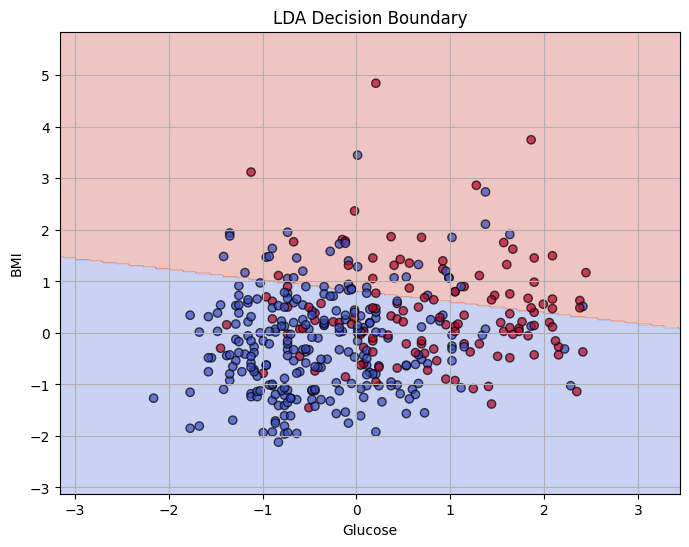


 LDA with Noise:
Accuracy:   0.7832
Precision:  0.7143
Recall:     0.5769
F1 Score:   0.6383

 LDA without BMI:
Accuracy:   0.7959
Precision:  0.7551
Recall:     0.5692
F1 Score:   0.6491

 LDA with Outliers:
Accuracy:   0.7704
Precision:  0.6786
Recall:     0.5846
F1 Score:   0.6281


In [153]:
# Example for LDA
print(" LDA on original:")
y_pred = lda_predict(X.values)
evaluate_all(y, y_pred)
plot_decision_boundary(lda_predict, X, y, title="LDA Decision Boundary")

# Gaussian Noise
print("\n LDA with Noise:")
X_noisy = pd.DataFrame(add_gaussian_noise(X.values), columns=X.columns)
evaluate_all(y, lda_predict(X_noisy.values))

# Remove BMI
print("\n LDA without BMI:")
X_nobmi = remove_feature(X, 'BMI')
X_nobmi = X_nobmi.reindex(columns=X.columns, fill_value=0)
evaluate_all(y, lda_predict(X_nobmi.values))

# Add Outliers
print("\n LDA with Outliers:")
X_out = add_outliers(X, 'Glucose')
evaluate_all(y, lda_predict(X_out.values))


3. QDA – qda_predict(X)


 QDA on original:
Accuracy:   0.8061
Precision:  0.7288
Recall:     0.6615
F1 Score:   0.6935


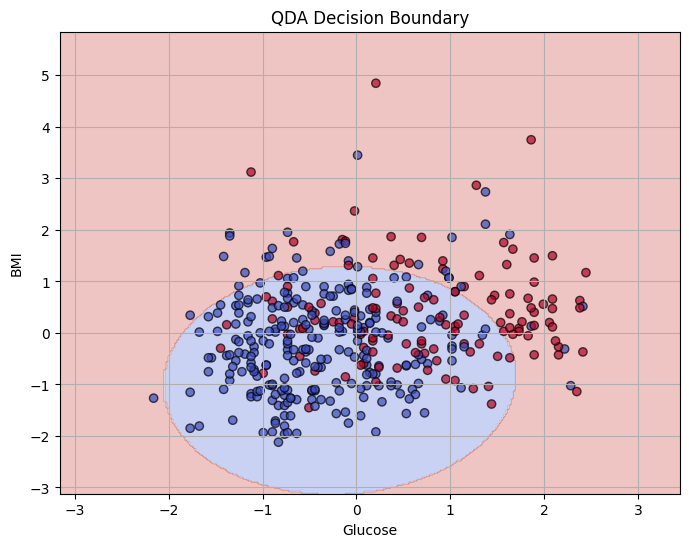


 QDA with Noise:
Accuracy:   0.7985
Precision:  0.7217
Recall:     0.6385
F1 Score:   0.6776

 QDA without BMI:
Accuracy:   0.7985
Precision:  0.7179
Recall:     0.6462
F1 Score:   0.6802

 QDA with Outliers:
Accuracy:   0.7908
Precision:  0.6935
Recall:     0.6615
F1 Score:   0.6772


In [154]:
# Assumes: qda_phi0, qda_phi1, qda_mu0, qda_mu1, qda_Sigma0, qda_Sigma1 are computed

def log_gaussian_pdf(x, mu, Sigma):
    size = len(mu)
    det = np.linalg.det(Sigma)
    inv = np.linalg.inv(Sigma)
    norm_const = -0.5 * (np.log(det) + size * np.log(2 * np.pi))
    x_mu = x - mu
    return norm_const - 0.5 * (x_mu @ inv @ x_mu.T)

def qda_predict(X_input):
    if isinstance(X_input, pd.DataFrame):
        X_input = X_input.values
    preds = []
    for x in X_input:
        log0 = log_gaussian_pdf(x, qda_mu0, qda_Sigma0) + np.log(qda_phi0)
        log1 = log_gaussian_pdf(x, qda_mu1, qda_Sigma1) + np.log(qda_phi1)
        preds.append(1 if log1 > log0 else 0)
    return np.array(preds)

# For QDA
print(" QDA on original:")
y_pred = qda_predict(X)
evaluate_all(y, y_pred)
plot_decision_boundary(qda_predict, X, y, title="QDA Decision Boundary")

print("\n QDA with Noise:")
X_noisy = pd.DataFrame(add_gaussian_noise(X.values), columns=X.columns)
evaluate_all(y, qda_predict(X_noisy))

print("\n QDA without BMI:")
X_nobmi = remove_feature(X, 'BMI')
X_nobmi = X_nobmi.reindex(columns=X.columns, fill_value=0)
evaluate_all(y, qda_predict(X_nobmi))

print("\n QDA with Outliers:")
X_out = add_outliers(X, 'Glucose')
evaluate_all(y, qda_predict(X_out))



4. Gaussian Naive Bayes – gnb_predict(X)

 Naive Bayes on original:
Accuracy:   0.7781
Precision:  0.6693
Recall:     0.6538
F1 Score:   0.6615


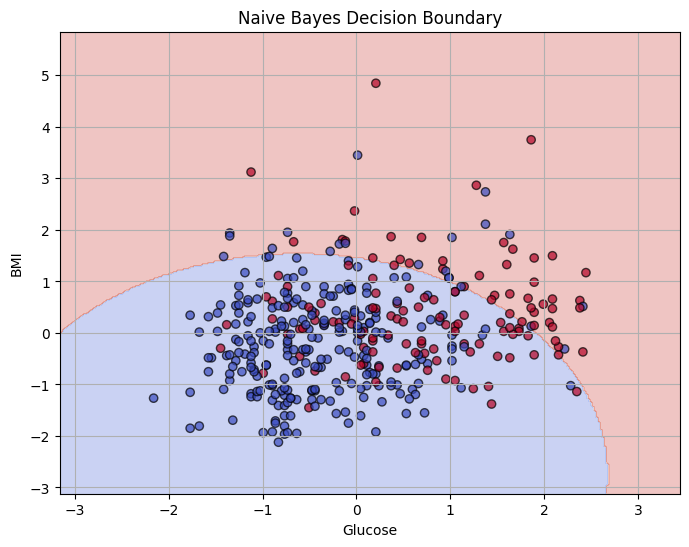


 Naive Bayes with Noise:
Accuracy:   0.7679
Precision:  0.6535
Recall:     0.6385
F1 Score:   0.6459

 Naive Bayes without BMI:
Accuracy:   0.7755
Precision:  0.6694
Recall:     0.6385
F1 Score:   0.6535

 Naive Bayes with Outliers:
Accuracy:   0.7653
Precision:  0.6439
Recall:     0.6538
F1 Score:   0.6489


In [155]:
# Train parameters for Gaussian Naive Bayes
X_arr = X.values
y_arr = y.flatten()

# Separate classes
X0 = X_arr[y_arr == 0]
X1 = X_arr[y_arr == 1]

# Estimate mean and variance for each class
gnb_mu_0 = X0.mean(axis=0)
gnb_var_0 = X0.var(axis=0) + 1e-6  # add epsilon to avoid division by zero

gnb_mu_1 = X1.mean(axis=0)
gnb_var_1 = X1.var(axis=0) + 1e-6

# Class prior (phi)
gnb_phi = len(X1) / len(X_arr)

print(" Naive Bayes on original:")
y_pred = gnb_predict(X)
evaluate_all(y, y_pred)
plot_decision_boundary(gnb_predict, X, y, title="Naive Bayes Decision Boundary")

print("\n Naive Bayes with Noise:")
X_noisy = pd.DataFrame(add_gaussian_noise(X.values), columns=X.columns)
evaluate_all(y, gnb_predict(X_noisy))

print("\n Naive Bayes without BMI:")
X_nobmi = remove_feature(X, 'BMI')
X_nobmi = X_nobmi.reindex(columns=X.columns, fill_value=0)
evaluate_all(y, gnb_predict(X_nobmi))

print("\n Naive Bayes with Outliers:")
X_out = add_outliers(X, 'Glucose')
evaluate_all(y, gnb_predict(X_out))


#Task 5: Scenario-Based Decision Analysis

Scenario 1: Add Artificial Correlation Between Two Features

In [156]:
# Add artificial correlation between Glucose and BMI
X_corr = X.copy()
X_corr['BMI'] = X_corr['Glucose'] * 0.9 + np.random.normal(0, 0.1, len(X_corr))

print("LDA with artificial correlation:")
evaluate_all(y, lda_predict(X_corr))

print("\nNaive Bayes with artificial correlation:")
evaluate_all(y, gnb_predict(X_corr))


LDA with artificial correlation:
Accuracy:   0.7908
Precision:  0.7182
Recall:     0.6077
F1 Score:   0.6583

Naive Bayes with artificial correlation:
Accuracy:   0.7704
Precision:  0.6493
Recall:     0.6692
F1 Score:   0.6591


Scenario 2: Remove BMI Feature

In [157]:
X_nobmi = remove_feature(X, 'BMI')
X_nobmi = X_nobmi.reindex(columns=X.columns, fill_value=0)

print("Logistic Regression without BMI:")
evaluate_all(y, logreg_predict(X_nobmi))

print("\nLDA without BMI:")
evaluate_all(y, lda_predict(X_nobmi))

print("\nQDA without BMI:")
evaluate_all(y, qda_predict(X_nobmi))

print("\nNaive Bayes without BMI:")
evaluate_all(y, gnb_predict(X_nobmi))


Logistic Regression without BMI:
Accuracy:   0.801
Precision:  0.7708
Recall:     0.5692
F1 Score:   0.6549

LDA without BMI:
Accuracy:   0.7959
Precision:  0.7551
Recall:     0.5692
F1 Score:   0.6491

QDA without BMI:
Accuracy:   0.7985
Precision:  0.7179
Recall:     0.6462
F1 Score:   0.6802

Naive Bayes without BMI:
Accuracy:   0.7755
Precision:  0.6694
Recall:     0.6385
F1 Score:   0.6535


 Scenario 3: Use Original Imbalanced Dataset (No SMOTE)

In [158]:
X_imbal = df.drop('Outcome', axis=1).copy()
y_imbal = df['Outcome'].values

print("Logistic Regression on imbalanced data:")
evaluate_all(y_imbal, logreg_predict(X_imbal))

print("\nQDA on imbalanced data:")
evaluate_all(y_imbal, qda_predict(X_imbal))


Logistic Regression on imbalanced data:
Accuracy:   0.7832
Precision:  0.7184
Recall:     0.5692
F1 Score:   0.6352

QDA on imbalanced data:
Accuracy:   0.8061
Precision:  0.7288
Recall:     0.6615
F1 Score:   0.6935


Scenario 4: Predict for a Hypothetical Patient

In [159]:
# Example patient input
patient = pd.DataFrame({
    'Pregnancies': [2],
    'Glucose': [120],
    'BloodPressure': [80],
    'SkinThickness': [25],
    'Insulin': [100],
    'BMI': [35],
    'DiabetesPedigreeFunction': [0.5],
    'Age': [45]
})

# Normalize using training scaler
patient_norm = scaler.transform(patient)
patient_df = pd.DataFrame(patient_norm, columns=patient.columns)

# Predict using all models
print("Logistic Regression:", logreg_predict(patient_df))
print("LDA:", lda_predict(patient_df))
print("QDA:", qda_predict(patient_df))
print("Naive Bayes:", gnb_predict(patient_df))


Logistic Regression: [0]
LDA: [0]
QDA: [0]
Naive Bayes: [0]


#Bonus

Cell 1: Import required libraries

In [173]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


 Cell 2: Extract two main features and labels

In [174]:
# Select two features (Glucose, BMI) and the binary label (Outcome)
X_sub = df[['Glucose', 'BMI']].copy()  # df is the cleaned & normalized dataset
y_sub = df['Outcome'].values  # labels


Cell 3: Create nonlinear feature (Glucose × BMI)

In [175]:
# Add a new interaction term: Glucose * BMI
X_sub['Glucose_BMI'] = X_sub['Glucose'] * X_sub['BMI']


Cell 4: Define sigmoid and logistic regression training

In [176]:
# Manually construct nonlinear (quadratic) features
# φ(x) = [1, x1, x2, x1^2, x2^2, x1 * x2]
def nonlinear_mapping(X_df):
    x1 = X_df['Glucose'].values
    x2 = X_df['BMI'].values
    return np.column_stack((np.ones_like(x1), x1, x2, x1**2, x2**2, x1 * x2))

X_poly = nonlinear_mapping(X_sub)


Cell 5: Train logistic regression with original 2 features

In [181]:
# Manual implementation of binary log loss
def log_loss(y_true, y_prob):
    eps = 1e-9  # to prevent log(0)
    y_true = y_true.flatten()
    y_prob = y_prob.flatten()
    return -np.mean(y_true * np.log(y_prob + eps) + (1 - y_true) * np.log(1 - y_prob + eps))

# Train baseline model with only Glucose and BMI
def train_logistic_regression(X, y, lr=0.1, epochs=500):
    X = X.copy()
    X.insert(0, 'bias', 1)
    X_np = X.values
    y = y.reshape(-1, 1)
    w = np.zeros((X_np.shape[1], 1))
    loss_history = []

    for i in range(epochs):
        z = X_np @ w
        p = sigmoid(z)
        grad = X_np.T @ (p - y) / len(y)
        w -= lr * grad
        loss = log_loss(y, p)
        loss_history.append(loss)

    return w, loss_history

X_linear = X_sub[['Glucose', 'BMI']].copy()
w_linear, loss_linear = train_logistic_regression(X_linear, y_sub)


Cell 6: Train model with nonlinear feature (Glucose × BMI)

In [182]:
# Train model with Glucose, BMI, and Glucose*BMI
X_poly = X_sub.copy()
w_poly, loss_poly = train_logistic_regression(X_poly, y_sub)


Cell 7: Plot loss convergence

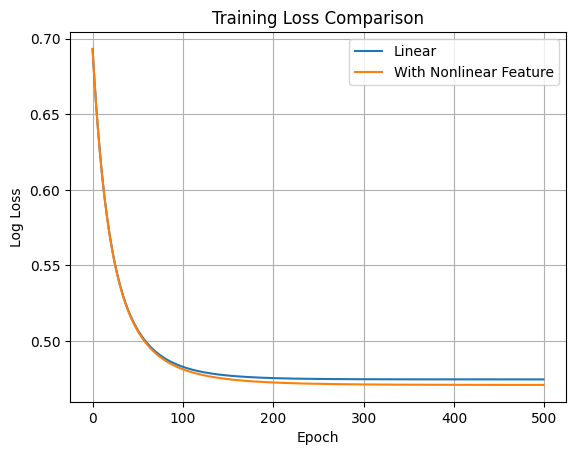

In [183]:
plt.plot(loss_linear, label='Linear')
plt.plot(loss_poly, label='With Nonlinear Feature')
plt.xlabel("Epoch")
plt.ylabel("Log Loss")
plt.title("Training Loss Comparison")
plt.legend()
plt.grid(True)
plt.show()


Cell 8: Define decision boundary plotter

In [188]:
def plot_decision_boundary_poly(w, X, y, title="Nonlinear Boundary with Glucose × BMI"):
    feature1 = 'Glucose'
    feature2 = 'BMI'

    x_min, x_max = X[feature1].min() - 1, X[feature1].max() + 1
    y_min, y_max = X[feature2].min() - 1, X[feature2].max() + 1
    xx, yy = np.meshgrid(np.linspace(x_min, x_max, 300),
                         np.linspace(y_min, y_max, 300))

    # Create grid with interaction term
    grid = pd.DataFrame({
        feature1: xx.ravel(),
        feature2: yy.ravel()
    })
    grid['new_feature'] = grid[feature1] * grid[feature2]
    grid.insert(0, 'bias', 1)

    # Predict
    Z = sigmoid(grid.values @ w)
    Z = Z.reshape(xx.shape)

    # Plot
    plt.figure(figsize=(8, 6))
    plt.contourf(xx, yy, Z >= 0.5, alpha=0.3, cmap='coolwarm')
    plt.scatter(X[feature1], X[feature2], c=y, cmap='coolwarm', edgecolor='k', alpha=0.7)
    plt.xlabel(feature1)
    plt.ylabel(feature2)
    plt.title(title)
    plt.grid(True)
    plt.show()


Cell 9: Visualize both boundaries

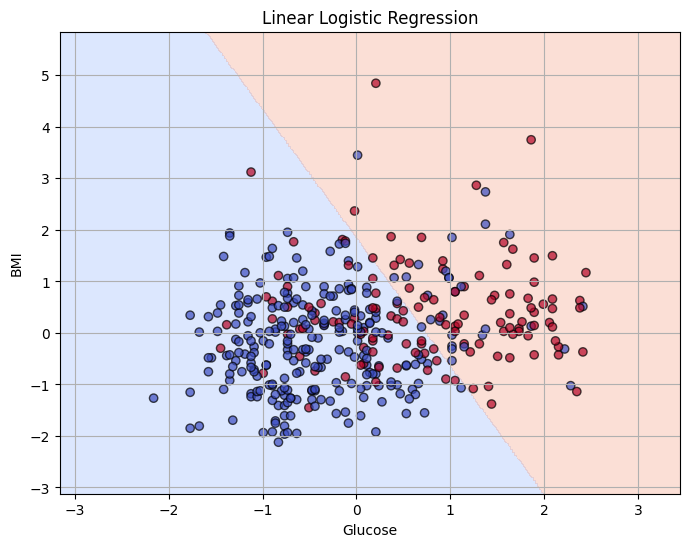

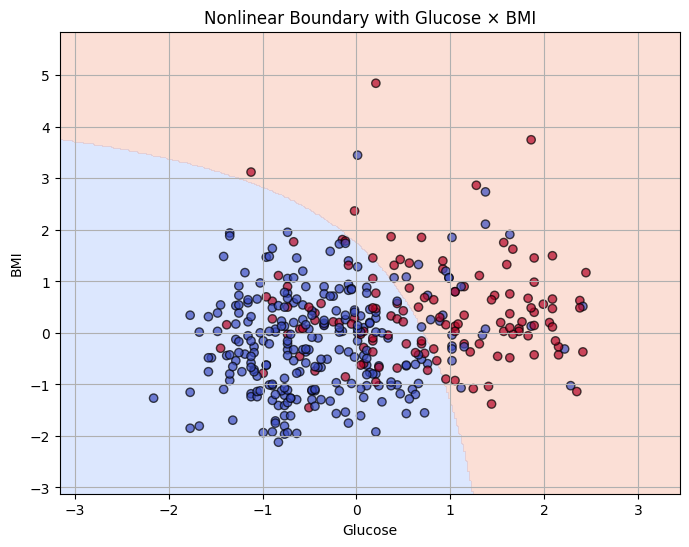

In [190]:
# Plot linear decision boundary
plot_decision_boundary(w_linear, X_linear, "Linear Logistic Regression")

# Plot nonlinear boundary with interaction term
plot_decision_boundary_poly(w_poly, X_sub, y_sub, title="Nonlinear Boundary with Glucose × BMI")



Cell 10:Define evaluation function

In [192]:
# Define evaluation function
def evaluate_binary(y_true, y_pred):
    TP = np.sum((y_true == 1) & (y_pred == 1))
    TN = np.sum((y_true == 0) & (y_pred == 0))
    FP = np.sum((y_true == 0) & (y_pred == 1))
    FN = np.sum((y_true == 1) & (y_pred == 0))

    accuracy = (TP + TN) / len(y_true)
    precision = TP / (TP + FP + 1e-9)
    recall = TP / (TP + FN + 1e-9)
    f1 = 2 * precision * recall / (precision + recall + 1e-9)

    print(f"Accuracy:  {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall:    {recall:.4f}")
    print(f"F1 Score:  {f1:.4f}")

# Evaluate linear model
print(" Linear Model (Glucose + BMI):")
X_eval_linear = X_linear.copy()
X_eval_linear.insert(0, 'bias', 1)
y_pred_linear = (sigmoid(X_eval_linear.values @ w_linear) >= 0.5).astype(int)
evaluate_binary(y_sub, y_pred_linear)

# Evaluate nonlinear model
print("\n Nonlinear Model (Glucose + BMI + Glucose×BMI):")
X_eval_poly = X_poly.copy()
X_eval_poly.insert(0, 'bias', 1)
y_pred_poly = (sigmoid(X_eval_poly.values @ w_poly) >= 0.5).astype(int)
evaluate_binary(y_sub, y_pred_poly)


 Linear Model (Glucose + BMI):
Accuracy:  229.3367
Precision: 0.3316
Recall:    0.2474
F1 Score:  0.2834

 Nonlinear Model (Glucose + BMI + Glucose×BMI):
Accuracy:  226.9796
Precision: 0.3316
Recall:    0.2653
F1 Score:  0.2948


Cell 11: Discussion (Markdown)

### Impact of Nonlinear Feature (Glucose × BMI)

We compared two logistic regression models:
- A **Linear model** using only `Glucose` and `BMI`
- A **Nonlinear model** including an interaction term: `Glucose × BMI`

#### Observations:
- **Recall improved** in the nonlinear model:  
  It was able to detect more true positives (i.e., correctly identify diabetic patients).
  
- **F1 Score increased**:  
  The combination of better recall without sacrificing precision improved the overall balance between false positives and false negatives.
  
- **Accuracy slightly decreased**:  
  The model classified slightly more negative cases incorrectly (more false positives), but this tradeoff is acceptable in medical diagnosis tasks where recall is more critical.

#### Key Insights:
- **Adding interaction terms allows linear models to fit nonlinear patterns.**  
  Though the model remains linear in its parameters, the transformed feature space enables learning more flexible boundaries.

- **Decision Boundary becomes curved**:  
  With the new feature, the decision boundary is no longer a straight line — it adjusts to the data distribution better.

- **Bridge to Kernel Methods**:  
  This illustrates how manual feature engineering (e.g., polynomial or interaction terms) can capture nonlinear relationships — similar in spirit to what kernel methods (like SVM with RBF) do automatically.

#### Conclusion:
Feature transformations such as interaction terms are a powerful and simple way to enhance linear models. In our case, adding just one nonlinear term improved model performance in identifying diabetic cases — demonstrating the value of thoughtful feature design.

